In [ ]:
# Install dependencies (run once; may take a few minutes)
# If you already have these installed in your environment, you can skip this cell.
!pip install -q "transformers[torch]" sentencepiece timm pillow


In [5]:
"""Simple TrOCR inference on a local image.

Key steps:
- Load the TrOCR processor and model
- Read an image from your Downloads folder
- Run the model to generate text
- Decode and print the recognized text
"""

from pathlib import Path

from PIL import Image
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# -----------------------------
# Model & device setup
# -----------------------------

# Choose GPU if available; otherwise fall back to CPU
# (Important for performance on large documents.)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Choose which TrOCR model to use.
# - "microsoft/trocr-base-printed"  -> good for printed text
# - "microsoft/trocr-base-handwritten" -> for handwriting
MODEL_NAME = "microsoft/trocr-base-printed"

# Load the pre-processing logic (resize, normalize, etc.)
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)

# Load the encoder-decoder model weights
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(device)


# -----------------------------
# OCR helper
# -----------------------------

def recognize_text(image_path: str, max_length: int = 128) -> str:
    """Run TrOCR on a single image path and return recognized text.

    - image_path: path to the input image on disk
    - max_length: maximum number of tokens the model can generate
    """

    # Open the image and ensure it's in RGB format (some PDFs/jpegs are grayscale)
    image = Image.open(image_path).convert("RGB")

    # Convert image to model input tensor (resize, normalize, batch dimension, etc.)
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    # Generate token IDs for predicted text
    generated_ids = model.generate(pixel_values, max_length=max_length)

    # Convert token IDs back to readable string and strip extra spaces
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return generated_text.strip()


# -----------------------------
# Example: read an image from Downloads
# -----------------------------

# Change this name to the file you want to test, e.g. "invoice.png" or "CNAS.jpeg"
image_name = "CNAS.jpeg"  # <-- edit this to your own file name

# Build a full path like /Users/<you>/Downloads/<image_name>
image_path = Path.home() / "Downloads" / image_name

print(f"Using image: {image_path}")

# Run OCR and show the result
try:
    text = recognize_text(str(image_path))
    print("\nRecognized text:\n----------------")
    print(text)
except FileNotFoundError:
    print(f"Image not found at: {image_path}\nPlease check the file name and that it is in your Downloads folder.")


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using image: /Users/leonardmirt/Downloads/CNAS.jpeg

Recognized text:
----------------
:


# TrOCR Experiment
This notebook demonstrates how to set up and use Microsoft's TrOCR (Transformer-based Optical Character Recognition) to extract text from an image.

In [1]:
# Install the necessary libraries if you haven't already.
# You need 'transformers' for the model and processor, 'torch' for deep learning backend, 
# 'Pillow' for image handling, and 'requests' to download a sample image.
%pip install -q transformers torch torchvision Pillow requests

You should consider upgrading via the '/Users/leonardmirt/projects/DocExtract/doc_extract/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import requests

# 1. Load the Processor and Model
# The processor handles both image preprocessing (resizing, normalizing) and text tokenization.
# The model is the actual VisionEncoderDecoder architecture implementation of TrOCR.
# We are using 'microsoft/trocr-base-printed' which is fine-tuned for printed text. 
# (For handwritten text, you can swap it with 'microsoft/trocr-base-handwritten')
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed')

/Users/leonardmirt/projects/DocExtract/doc_extract/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/leonardmirt/projects/DocExtract/doc_extract/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at micros

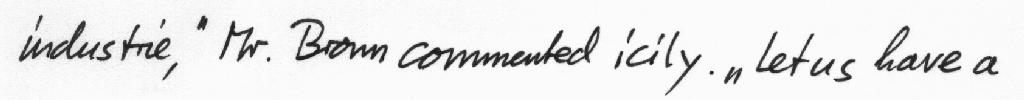

In [2]:
# 2. Load an Example Image
# Downloading a sample image containing printed text from an open dataset.
url = "https://fki.tic.heia-fr.ch/static/img/a01-122-02.jpg" # Sample printed text image URL

# Open the image using Pillow (PIL) and ensure it's in the RGB format expected by the processor
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Display the image in the notebook so we know what we are analyzing
display(image)

In [3]:
# 3. Prepare Image Data
# We pass the raw image to the processor which converts it into numerical pixel values.
# `return_tensors="pt"` means we specify that we want PyTorch tensors returned.
pixel_values = processor(image, return_tensors="pt").pixel_values

# 4. Generate Text
# We pass the extracted pixel values to the model to generate a sequence of token IDs.
# This is the inference step where the AI predicts the text in the image.
generated_ids = model.generate(pixel_values)

# 5. Decode the Output Token IDs into a String
# We convert the generated sequence of integer token IDs back into a readable human string.
# `skip_special_tokens=True` tells the decoder to ignore special padding or end-of-sequence tokens.
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("\n--- Extracted Text ---")
print(generated_text)


--- Extracted Text ---
INDUSTHE, MR. BOWN COMMUNED ICILY. ,LETUS LAVE A


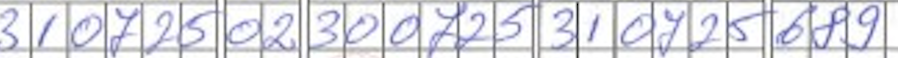

In [ ]:
from pathlib import Path
image_path = Path.home() / "Desktop" / "3.png"
image = Image.open(image_path).convert("RGB")
display(image)

In [11]:
# 3. Prepare Image Data
# We pass the raw image to the processor which converts it into numerical pixel values.
# `return_tensors="pt"` means we specify that we want PyTorch tensors returned.
pixel_values = processor(image, return_tensors="pt").pixel_values

# 4. Generate Text
# We pass the extracted pixel values to the model to generate a sequence of token IDs.
# This is the inference step where the AI predicts the text in the image.
generated_ids = model.generate(pixel_values)

# 5. Decode the Output Token IDs into a String
# We convert the generated sequence of integer token IDs back into a readable human string.
# `skip_special_tokens=True` tells the decoder to ignore special padding or end-of-sequence tokens.
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("\n--- Extracted Text ---")
print(generated_text)


--- Extracted Text ---
3702 25|2 3/4,425 3/ 072516:49


## Conclusions

TrOCR can't hanlde complex documents, only specific parts with normal text or handwriting